## 3. Load, clean, and balance the dataset

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
DATA_PATH = "/content/drive/MyDrive/kaggle_datasets/QSNET_DATASETS/UNSW"

df_train   = pd.read_parquet(f"{DATA_PATH}/q8_train.parquet")
df_test    = pd.read_parquet(f"{DATA_PATH}/q8_test.parquet")
df_cal     = pd.read_parquet(f"{DATA_PATH}/q8_calibration.parquet")
df_zeroday = pd.read_parquet(f"{DATA_PATH}/q8_zeroday.parquet")

for name, df in [("train", df_train), ("test", df_test), ("cal", df_cal), ("zeroday", df_zeroday)]:
    print(f"{name:8s}: {df.shape}")
df_train.head()

train   : (84730, 11)
test    : (12104, 11)
cal     : (12104, 11)
zeroday : (1615, 11)


,sttl,dttl,dload,ct_state_ttl,state,dinpkt,ackdat,tcprtt,label_multiclass,label_binary,label_family
0,0.763838,3.129175,2.660748,0.523599,1.396263,0.567328,0.134491,0.105801,Exploits,1,exploits
1,0.763838,3.129175,1.300715,1.570796,0.698132,0.002002,0.579657,0.487356,Normal,0,benign
2,3.129273,0.000000,0.000000,1.047198,1.745329,0.000000,0.000000,0.000000,Generic,1,generic
3,3.129273,3.129175,1.547429,0.523599,1.396263,1.360604,0.214320,0.311306,Normal,0,benign
4,0.381919,0.360104,2.342302,0.000000,1.396263,0.580307,0.000398,0.001232,Normal,0,benign


In [ ]:
df_train.label_multiclass.value_counts()

,count
label_multiclass,
Normal,46891
Exploits,14710
Fuzzers,10619
Generic,4788
Reconnaissance,4721
DoS,2411
Analysis,333
Backdoor,257


In [ ]:
df_cal.label_multiclass.value_counts()

,count
label_multiclass,
Normal,6698
Exploits,2102
Fuzzers,1517
Generic,684
Reconnaissance,674
DoS,345
Analysis,48
Backdoor,36


In [ ]:
for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_binary"], inplace=True, errors="ignore")

def clean_features(df, feature_cols):
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    n_before = len(df)
    df = df[df[feature_cols].isna().mean(axis=1) < 0.5]
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
    df[feature_cols] = df[feature_cols].fillna(0.0)
    if len(df) < n_before:
        print(f"  dropped {n_before - len(df)} rows with excessive missing values")
    return df.reset_index(drop=True)

_feature_cols_raw = [c for c in df_train.columns if c != "label_multiclass"]
print(f"Raw numeric feature columns ({len(_feature_cols_raw)}): {_feature_cols_raw}")

df_train   = clean_features(df_train,   _feature_cols_raw)
df_test    = clean_features(df_test,    _feature_cols_raw)
df_cal     = clean_features(df_cal,     _feature_cols_raw)
df_zeroday = clean_features(df_zeroday, _feature_cols_raw)

MAX_CLASSES = 6
top_classes = df_train.label_multiclass.value_counts().head(MAX_CLASSES).index.tolist()
print(f"\nUsing top {len(top_classes)} classes: {top_classes}")

df_train_f   = df_train[df_train.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_test_f    = df_test[df_test.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_cal_f     = df_cal[df_cal.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_zeroday_f = df_zeroday.reset_index(drop=True)

le = LabelEncoder(); le.fit(top_classes)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"Encoded classes ({N_CLASSES}): {dict(enumerate(CLASS_NAMES))}")

feature_columns = [c for c in df_train.columns if c != "label_multiclass"]
target_column = "label_multiclass"

Raw numeric feature columns (8): ['sttl', 'dttl', 'dload', 'ct_state_ttl', 'state', 'dinpkt', 'ackdat', 'tcprtt']

Using top 6 classes: ['Normal', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'DoS']
Encoded classes (6): {0: np.str_('DoS'), 1: np.str_('Exploits'), 2: np.str_('Fuzzers'), 3: np.str_('Generic'), 4: np.str_('Normal'), 5: np.str_('Reconnaissance')}


In [ ]:
from collections import Counter

SEED = 42

def capped_sample(X_raw, y_raw, per_class_cap, seed):
    np.random.seed(seed)
    X_sampled = []
    y_sampled = []
    unique_classes = np.unique(y_raw)

    for cls in unique_classes:
        class_indices = np.where(y_raw == cls)[0]
        if len(class_indices) > per_class_cap:
            sampled_indices = np.random.choice(class_indices, size=per_class_cap, replace=False)
        else:
            sampled_indices = class_indices
        X_sampled.append(X_raw[sampled_indices])
        y_sampled.append(y_raw[sampled_indices])

    if not X_sampled:
        return np.empty((0, X_raw.shape[1])), np.empty((0,))

    return np.vstack(X_sampled), np.concatenate(y_sampled)

def stratified_head(X_raw, y_raw, n, seed):
    np.random.seed(seed)
    X_sampled = []
    y_sampled = []

    unique_classes, raw_counts = np.unique(y_raw, return_counts=True)
    total_raw_samples = len(y_raw)

    target_samples_per_class = {}
    for i, cls in enumerate(unique_classes):
        prop = raw_counts[i] / total_raw_samples
        target_samples_per_class[cls] = int(prop * n)

    current_sum = sum(target_samples_per_class.values())
    diff = n - current_sum

    if diff != 0:
        class_remainders = []
        for i, cls in enumerate(unique_classes):
            prop = raw_counts[i] / total_raw_samples
            remainder = (prop * n) - target_samples_per_class[cls]
            class_remainders.append((cls, remainder))

        class_remainders.sort(key=lambda x: x[1], reverse=(diff > 0))

        for i in range(abs(diff)):
            cls_to_adjust = class_remainders[i % len(class_remainders)][0]
            if diff > 0:
                target_samples_per_class[cls_to_adjust] += 1
            else:
                target_samples_per_class[cls_to_adjust] -= 1

    for cls in unique_classes:
        class_indices = np.where(y_raw == cls)[0]
        num_to_sample = min(target_samples_per_class.get(cls, 0), len(class_indices))

        if num_to_sample > 0:
            sampled_indices = np.random.choice(class_indices, size=num_to_sample, replace=False)
            X_sampled.append(X_raw[sampled_indices])
            y_sampled.append(y_raw[sampled_indices])

    if not X_sampled:
        return np.empty((0, X_raw.shape[1])), np.empty((0,))

    return np.vstack(X_sampled), np.concatenate(y_sampled)

def class_balance_table(y, CLASS_NAMES):
    counts = Counter(y)
    total = len(y)
    print("\nClass Balance Table:")
    print("--------------------")
    print(f"{'Class Name':<20} {'Count':<10} {'Percentage':<10}")
    print("--------------------")

    sorted_class_indices = sorted(counts.keys())

    for cls_idx in sorted_class_indices:
        count = counts[cls_idx]
        percentage = (count / total) * 100
        class_name = CLASS_NAMES[cls_idx] if cls_idx < len(CLASS_NAMES) else f"Unknown_Class_{cls_idx}"
        print(f"{class_name:<20} {count:<10} {percentage:<9.2f}%")
    print("--------------------")
    print(f"{'Total':<20} {total:<10} {100.00:<9.2f}%")

PER_CLASS_CAP = 500
CAL_TEST_CAP  = 4000
ZERODAY_CAP   = 1500

X_train_raw = df_train_f[feature_columns].values
y_train_raw = le.transform(df_train_f[target_column])
X_train, y_train = capped_sample(X_train_raw, y_train_raw, per_class_cap=PER_CLASS_CAP, seed=SEED)

X_test_raw = df_test_f[feature_columns].values
y_test_raw = le.transform(df_test_f[target_column])
X_test, y_test = stratified_head(X_test_raw, y_test_raw, n=CAL_TEST_CAP, seed=SEED)

X_cal_raw = df_cal_f[feature_columns].values
y_cal_raw = le.transform(df_cal_f[target_column])
X_cal, y_cal = stratified_head(X_cal_raw, y_cal_raw, n=CAL_TEST_CAP, seed=SEED)

X_zeroday = df_zeroday_f[feature_columns].values[:ZERODAY_CAP]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}  X_cal: {X_cal.shape}  X_zeroday: {X_zeroday.shape}")
class_balance_table(y_train, CLASS_NAMES)


X_train: (3000, 8)  X_test: (4000, 8)  X_cal: (4000, 8)  X_zeroday: (1500, 8)

Class Balance Table:
--------------------
Class Name           Count      Percentage
--------------------
DoS                  500        16.67    %
Exploits             500        16.67    %
Fuzzers              500        16.67    %
Generic              500        16.67    %
Normal               500        16.67    %
Reconnaissance       500        16.67    %
--------------------
Total                3000       100.00   %


In [ ]:
N_QUBITS = 8
N_LAYERS = 3
REUPLOAD = True


TRAIN_BATCH_SIZE = 8
QBATCH           = 8
CACHE_BATCH      = 256

n_raw_features = len(feature_columns)
print(f"Raw numeric feature columns available: {n_raw_features}")
if n_raw_features <= N_QUBITS:
    print(f"NOTE: {n_raw_features} <= N_QUBITS={N_QUBITS}, so PCA performs NO dimensionality "
          f"reduction here -- it only rotates/decorrelates the existing features. Report this "
          f"as 'PCA-decorrelated' rather than 'PCA-compressed' in the methods section.")

scaler = StandardScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_test_scaled    = scaler.transform(X_test)
X_cal_scaled     = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca   = pca.fit_transform(X_train_scaled)
X_test_pca    = pca.transform(X_test_scaled)
X_cal_pca     = pca.transform(X_cal_scaled)
X_zeroday_pca = pca.transform(X_zeroday_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"PCA components kept: {N_QUBITS}.  Cumulative explained variance: {cum_var[-1]*100:.2f}%")

def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi

A_train, A_test, A_cal, A_zeroday = (to_angles(X_train_pca), to_angles(X_test_pca),
                                      to_angles(X_cal_pca), to_angles(X_zeroday_pca))
print(f"A_train: {A_train.shape}   N_CLASSES = {N_CLASSES}")

Raw numeric feature columns available: 8
NOTE: 8 <= N_QUBITS=8, so PCA performs NO dimensionality reduction here -- it only rotates/decorrelates the existing features. Report this as 'PCA-decorrelated' rather than 'PCA-compressed' in the methods section.
PCA components kept: 8.  Cumulative explained variance: 100.00%
A_train: (3000, 8)   N_CLASSES = 6


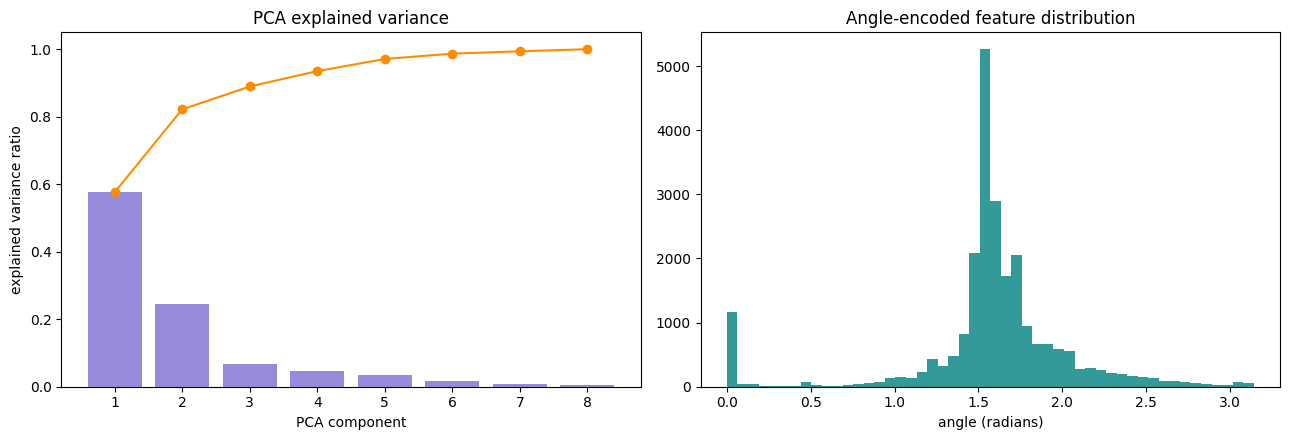

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, N_QUBITS + 1), pca.explained_variance_ratio_, color="slateblue", alpha=0.7)
ax[0].plot(range(1, N_QUBITS + 1), cum_var, marker="o", color="darkorange")
ax[0].set_xlabel("PCA component"); ax[0].set_ylabel("explained variance ratio"); ax[0].set_title("PCA explained variance")
ax[1].hist(A_train.flatten(), bins=50, color="teal", alpha=0.8)
ax[1].set_xlabel("angle (radians)"); ax[1].set_title("Angle-encoded feature distribution")
plt.tight_layout(); plt.show()

Training Random Forest...
Random Forest Accuracy: 64.75%


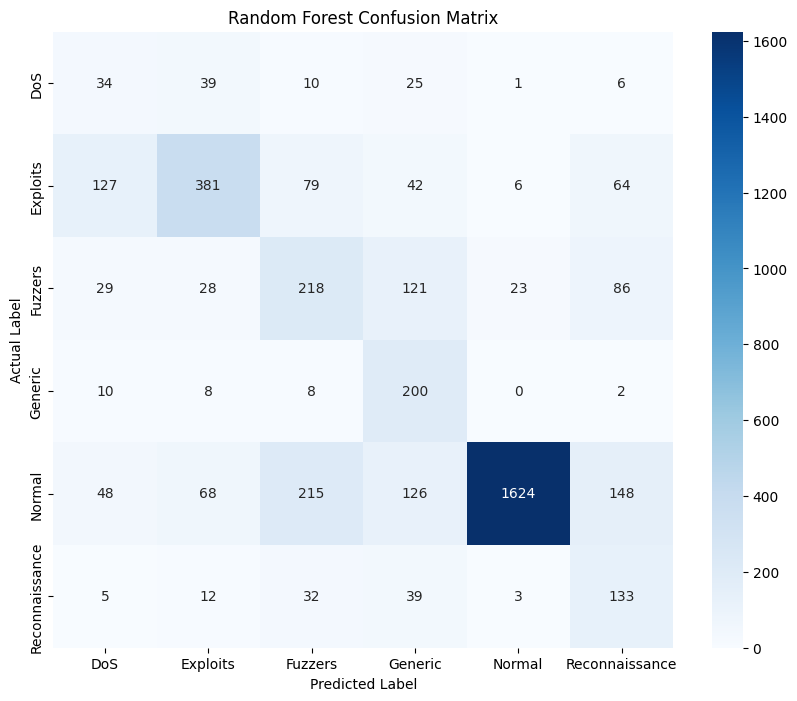


Classification Report:
                precision    recall  f1-score   support

           DoS       0.13      0.30      0.18       115
      Exploits       0.71      0.55      0.62       699
       Fuzzers       0.39      0.43      0.41       505
       Generic       0.36      0.88      0.51       228
        Normal       0.98      0.73      0.84      2229
Reconnaissance       0.30      0.59      0.40       224

      accuracy                           0.65      4000
     macro avg       0.48      0.58      0.49      4000
  weighted avg       0.76      0.65      0.68      4000



In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)


print("Training Random Forest...")
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Training Random Forest (model2) on full dataset...
Random Forest (model2) Full Dataset Accuracy: 72.15%


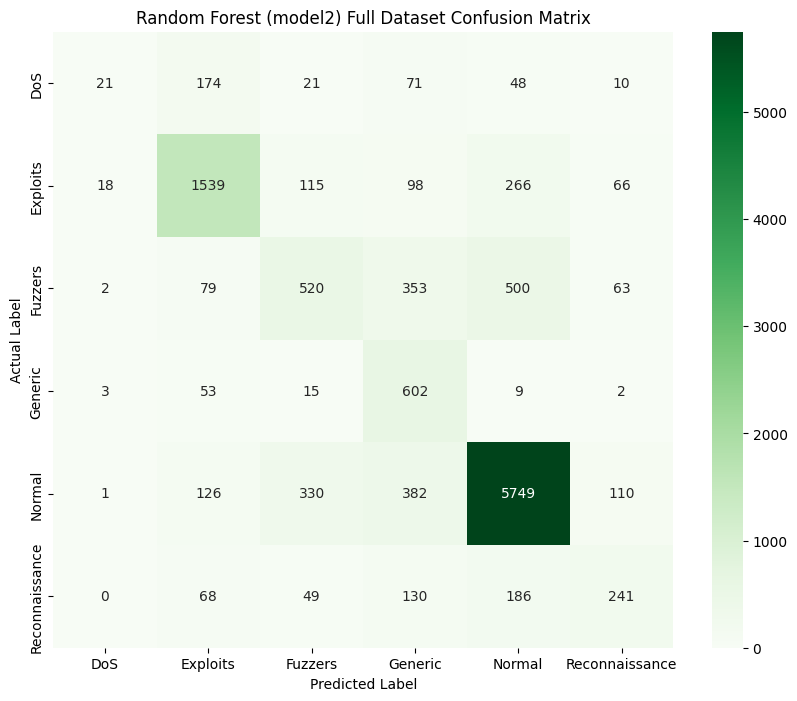


Classification Report (model2):
                precision    recall  f1-score   support

           DoS       0.47      0.06      0.11       345
      Exploits       0.75      0.73      0.74      2102
       Fuzzers       0.50      0.34      0.41      1517
       Generic       0.37      0.88      0.52       684
        Normal       0.85      0.86      0.85      6698
Reconnaissance       0.49      0.36      0.41       674

      accuracy                           0.72     12020
     macro avg       0.57      0.54      0.51     12020
  weighted avg       0.73      0.72      0.71     12020



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

print("Training Random Forest (model2) on full dataset...")

rf_model2.fit(X_train_raw, y_train_raw)


y_pred2 = rf_model2.predict(X_test_raw)

accuracy2 = accuracy_score(y_test_raw, y_pred2)
print(f"Random Forest (model2) Full Dataset Accuracy: {accuracy2 * 100:.2f}%")

cm2 = confusion_matrix(y_test_raw, y_pred2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Random Forest (model2) Full Dataset Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report (model2):")
print(classification_report(y_test_raw, y_pred2, target_names=CLASS_NAMES))

/tmp/ipykernel_2902/4110954854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vis_df, x='label_multiclass', y=col, palette='viridis')
/tmp/ipykernel_2902/4110954854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vis_df, x='label_multiclass', y=col, palette='viridis')
/tmp/ipykernel_2902/4110954854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vis_df, x='label_multiclass', y=col, palette='viridis')
/tmp/ipykernel_2902/4110954854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

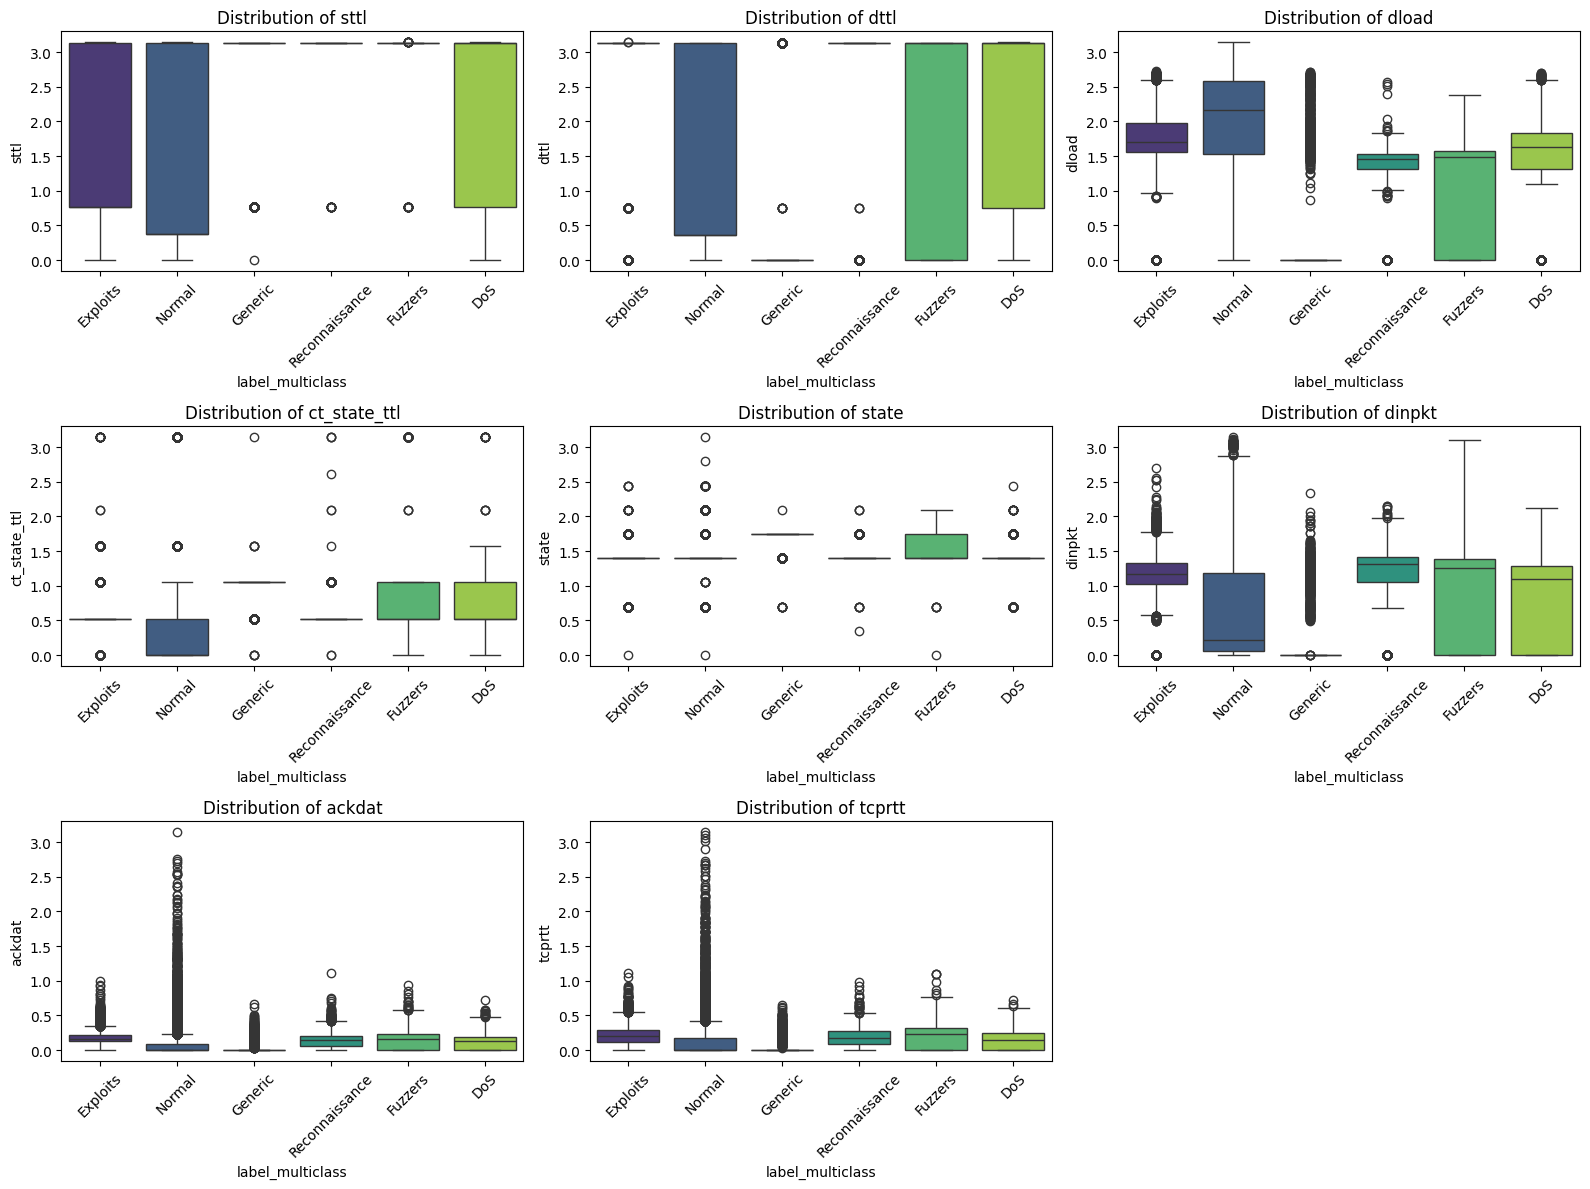

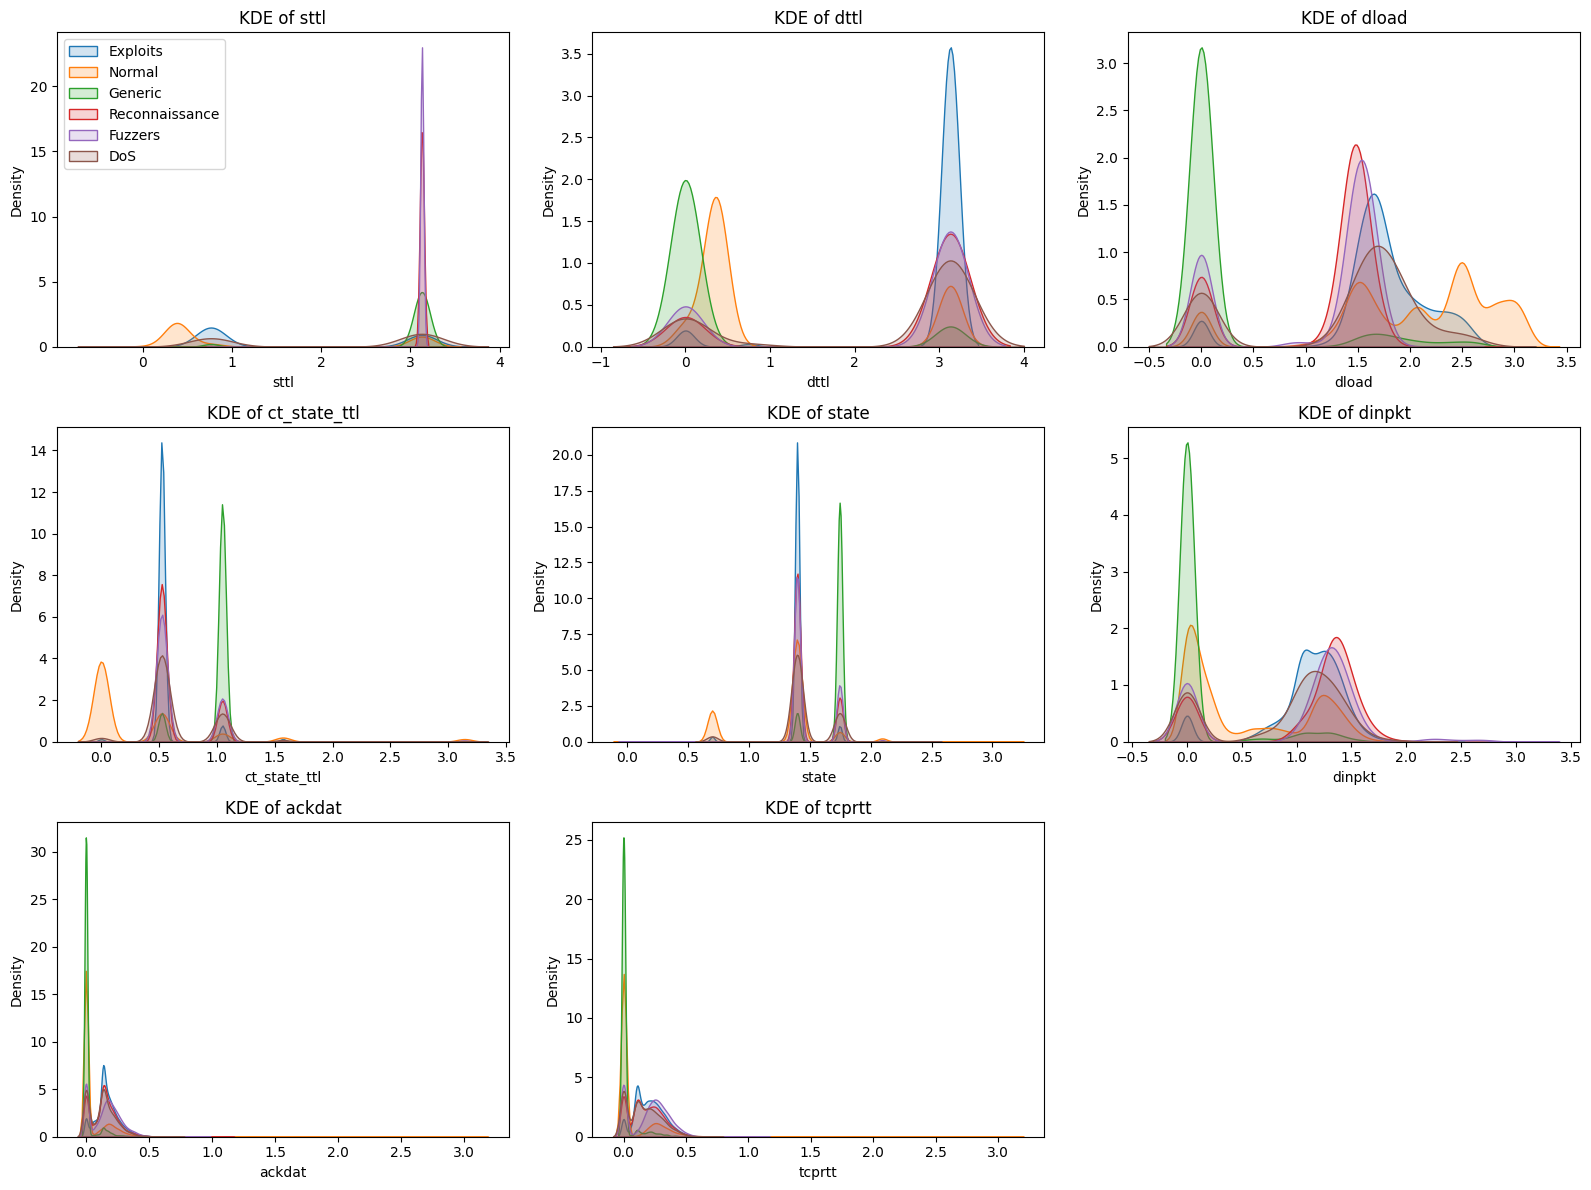

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

vis_df = df_train_f.copy()


plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=vis_df, x='label_multiclass', y=col, palette='viridis')
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_columns):
    plt.subplot(3, 3, i+1)
    for cls in vis_df['label_multiclass'].unique():
        subset = vis_df[vis_df['label_multiclass'] == cls]
        sns.kdeplot(subset[col], label=cls, fill=True, alpha=0.2)
    plt.title(f'KDE of {col}')
    if i == 0: plt.legend()
plt.tight_layout()
plt.show()

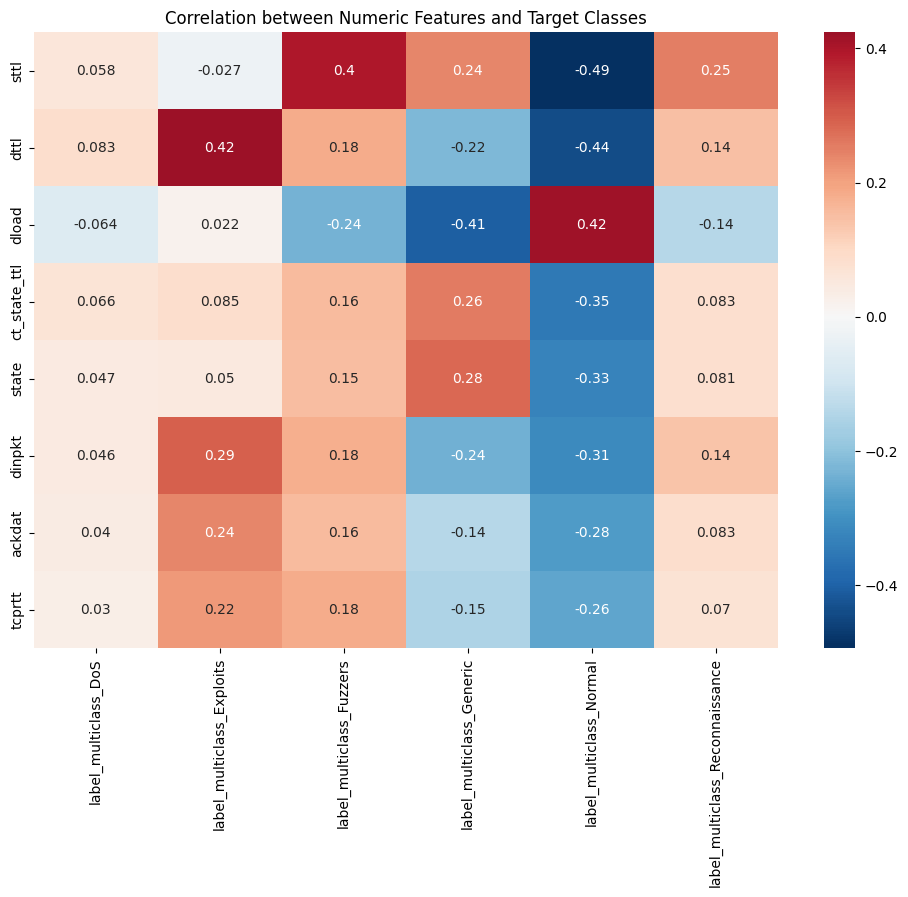

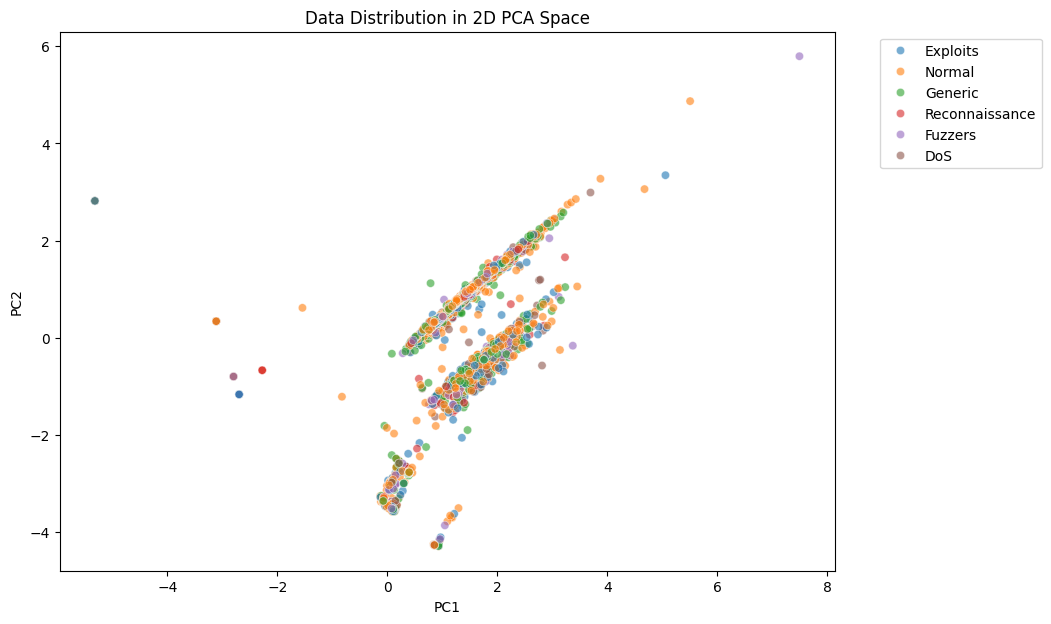

In [ ]:

dummy_df = pd.get_dummies(vis_df, columns=['label_multiclass'])
corr_matrix = dummy_df.corr()

class_cols = [c for c in corr_matrix.columns if 'label_multiclass_' in c]
feature_class_corr = corr_matrix.loc[feature_columns, class_cols]

plt.figure(figsize=(12, 8))
sns.heatmap(feature_class_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation between Numeric Features and Target Classes')
plt.show()


plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],
                hue=vis_df.loc[vis_df.index[:len(X_train_pca)], 'label_multiclass'],
                palette='tab10', alpha=0.6)
plt.title('Data Distribution in 2D PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=SEED)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)


plot_df = pd.DataFrame(
    X_train_pca_3d,
    columns=['PC1', 'PC2', 'PC3']
)

plot_df['Class'] = [CLASS_NAMES[i] for i in y_train]


fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Class',
    title='Interactive 3D PCA Visualization of Network Classes',
    labels={'PC1': 'First Component', 'PC2': 'Second Component', 'PC3': 'Third Component'},
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

Training advanced XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Improved XGBoost Accuracy: 72.85%


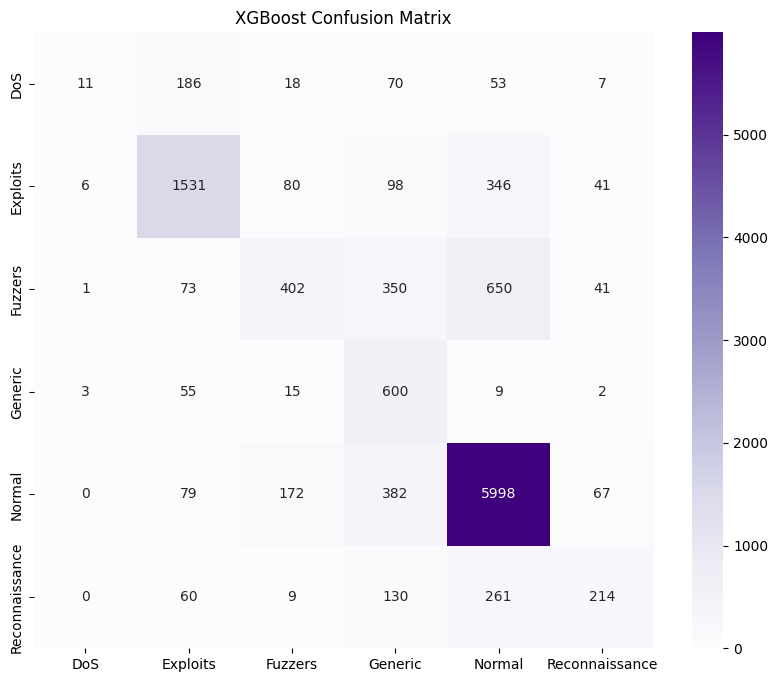


Classification Report (XGBoost):
                precision    recall  f1-score   support

           DoS       0.52      0.03      0.06       345
      Exploits       0.77      0.73      0.75      2102
       Fuzzers       0.58      0.26      0.36      1517
       Generic       0.37      0.88      0.52       684
        Normal       0.82      0.90      0.86      6698
Reconnaissance       0.58      0.32      0.41       674

      accuracy                           0.73     12020
     macro avg       0.61      0.52      0.49     12020
  weighted avg       0.73      0.73      0.71     12020



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training advanced XGBoost model...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='mlogloss'
)


xgb_model.fit(X_train_raw, y_train_raw)

y_pred_xgb = xgb_model.predict(X_test_raw)
accuracy_xgb = accuracy_score(y_test_raw, y_pred_xgb)

print(f"\nImproved XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_xgb = confusion_matrix(y_test_raw, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('XGBoost Confusion Matrix')
plt.show()

print("\nClassification Report (XGBoost):")
print(classification_report(y_test_raw, y_pred_xgb, target_names=CLASS_NAMES))

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

print("Training advanced XGBoost model...")


xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='mlogloss'
)


xgb_model.fit(X_train_raw, y_train_raw)


y_pred_xgb = xgb_model.predict(X_test_raw)
accuracy_xgb = accuracy_score(y_test_raw, y_pred_xgb)

print(f"\nImproved XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_raw, y_pred_xgb, target_names=CLASS_NAMES))

Training advanced XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Improved XGBoost Accuracy: 72.85%

Classification Report (XGBoost):
                precision    recall  f1-score   support

           DoS       0.52      0.03      0.06       345
      Exploits       0.77      0.73      0.75      2102
       Fuzzers       0.58      0.26      0.36      1517
       Generic       0.37      0.88      0.52       684
        Normal       0.82      0.90      0.86      6698
Reconnaissance       0.58      0.32      0.41       674

      accuracy                           0.73     12020
     macro avg       0.61      0.52      0.49     12020
  weighted avg       0.73      0.73      0.71     12020



### 6. Comparative Analysis: Training vs. Zero-Day Dataset
We will compare the class distributions of the training data and the zero-day data to see how the 'novel' or 'unseen' traffic in the zero-day set relates to our known training classes.

Class Distribution Comparison (Percentages):


,Train Share,Zero-Day Share,Diff (ZD - Train)
label_multiclass,,,
Normal,55.34%,0.00%,-55.34%
Exploits,17.36%,0.00%,-17.36%
Fuzzers,12.53%,0.00%,-12.53%
Generic,5.65%,0.00%,-5.65%
Reconnaissance,5.57%,0.00%,-5.57%
DoS,2.85%,0.00%,-2.85%
Analysis,0.39%,0.00%,-0.39%
Backdoor,0.30%,0.00%,-0.30%
Shellcode,0.00%,89.72%,89.72%


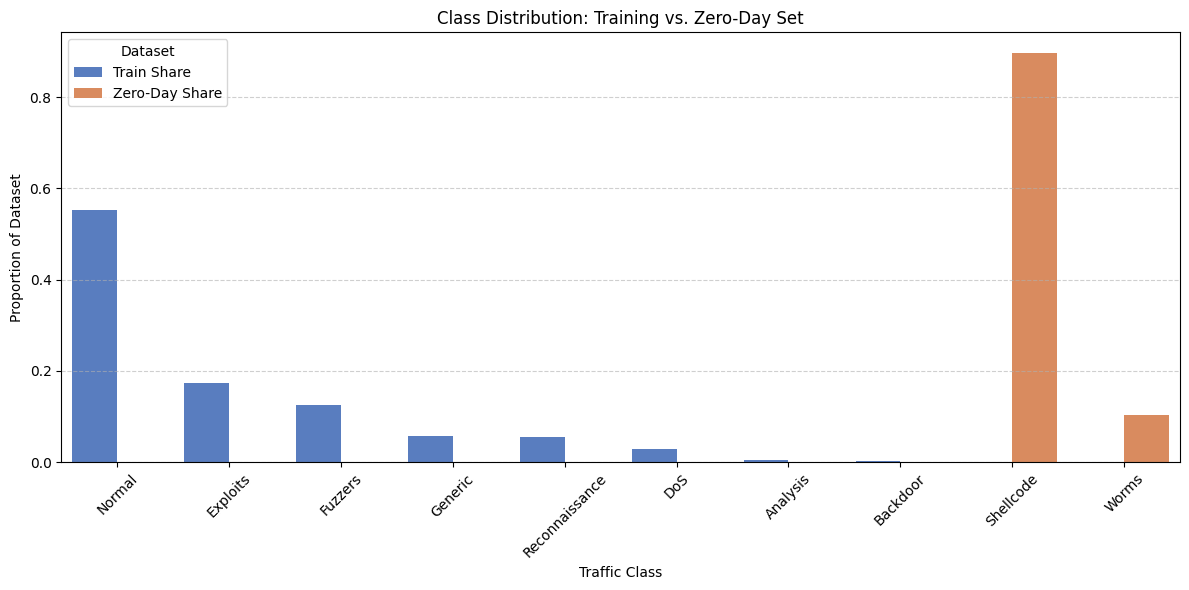

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

train_dist = df_train['label_multiclass'].value_counts(normalize=True).rename('Train Share')
zeroday_dist = df_zeroday['label_multiclass'].value_counts(normalize=True).rename('Zero-Day Share')


comparison_df = pd.concat([train_dist, zeroday_dist], axis=1).fillna(0)
comparison_df['Diff (ZD - Train)'] = comparison_df['Zero-Day Share'] - comparison_df['Train Share']

print("Class Distribution Comparison (Percentages):")
display(comparison_df.style.format('{:.2%}'))


comp_plot_df = comparison_df[['Train Share', 'Zero-Day Share']].reset_index().melt(id_vars='label_multiclass', var_name='Dataset', value_name='Percentage')

plt.figure(figsize=(12, 6))
sns.barplot(data=comp_plot_df, x='label_multiclass', y='Percentage', hue='Dataset', palette='muted')
plt.title('Class Distribution: Training vs. Zero-Day Set')
plt.ylabel('Proportion of Dataset')
plt.xlabel('Traffic Class')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

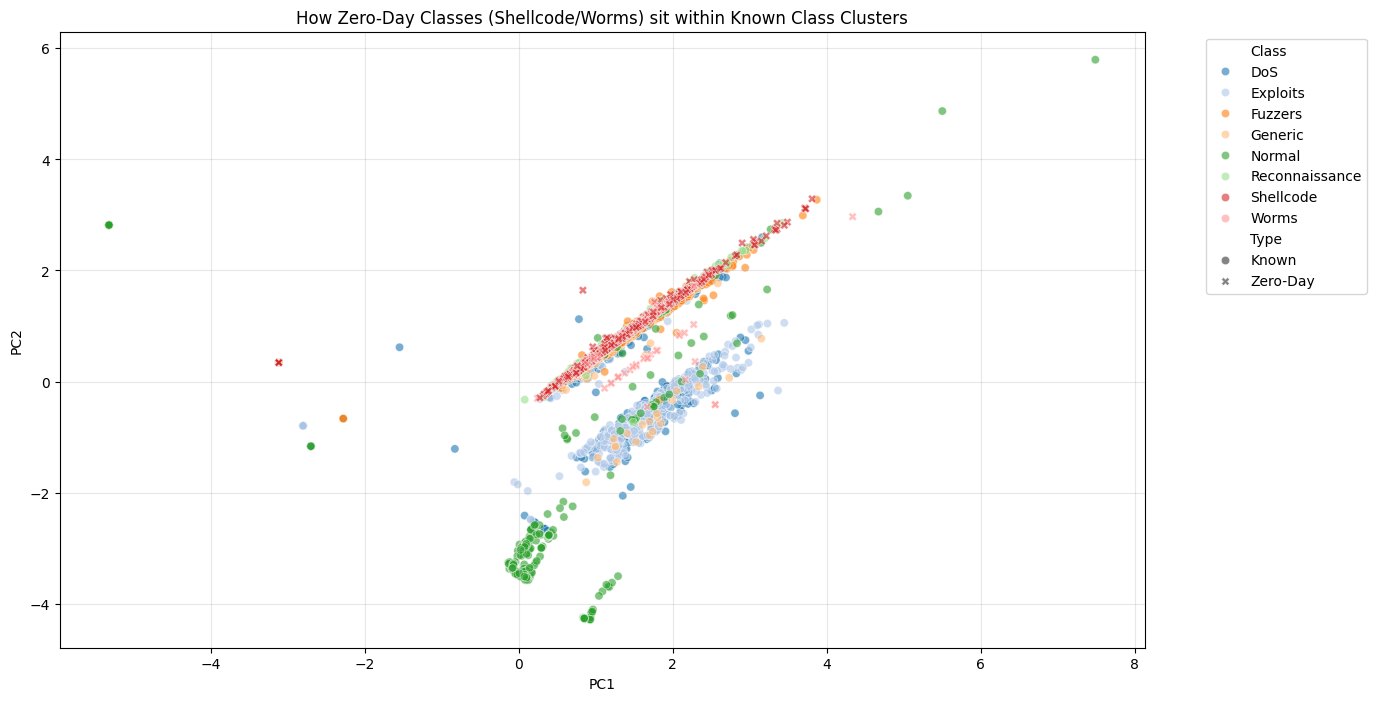

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

known_pca = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
known_pca['Class'] = [CLASS_NAMES[i] for i in y_train]
known_pca['Type'] = 'Known'


# Use the already calculated X_zeroday_pca (first 2 components)
zd_pca = pd.DataFrame(X_zeroday_pca[:, :2], columns=['PC1', 'PC2'])
zd_pca['Class'] = df_zeroday['label_multiclass'].iloc[:ZERODAY_CAP].values
zd_pca['Type'] = 'Zero-Day'


combined_pca = pd.concat([known_pca, zd_pca])

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=combined_pca,
    x='PC1',
    y='PC2',
    hue='Class',
    style='Type',
    alpha=0.6,
    palette='tab20'
)
plt.title('How Zero-Day Classes (Shellcode/Worms) sit within Known Class Clusters')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

X_train_normal = X_train_scaled[y_train == le.transform(['Normal'])[0]]


iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED)
iso_forest.fit(X_train_normal)


scores_test = iso_forest.decision_function(X_test_scaled)
scores_zd = iso_forest.decision_function(X_zeroday_scaled)


normal_test_indices = np.where(y_test == le.transform(['Normal'])[0])[0]
normal_test_scores = scores_test[normal_test_indices]
threshold = np.percentile(normal_test_scores, 5)

print(f"Anomaly Threshold (5th percentile of normal): {threshold:.4f}")


zd_rejected = np.sum(scores_zd < threshold)
zd_rejection_rate = zd_rejected / len(scores_zd)

print(f"Zero-Day Rejection Rate: {zd_rejection_rate:.2%}")
print(f"Total Zero-Day samples flagged as Anomaly: {zd_rejected} out of {len(scores_zd)}")

Anomaly Threshold (5th percentile of normal): -0.0004
Zero-Day Rejection Rate: 0.20%
Total Zero-Day samples flagged as Anomaly: 3 out of 1500


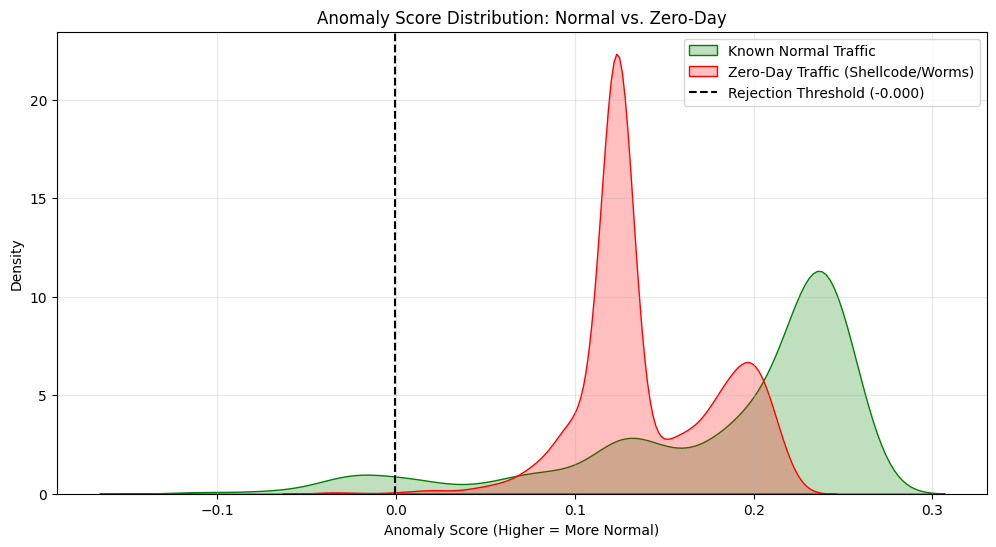

In [ ]:

plt.figure(figsize=(12, 6))
sns.kdeplot(normal_test_scores, label='Known Normal Traffic', fill=True, color='green')
sns.kdeplot(scores_zd, label='Zero-Day Traffic (Shellcode/Worms)', fill=True, color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Rejection Threshold ({threshold:.3f})')

plt.title('Anomaly Score Distribution: Normal vs. Zero-Day')
plt.xlabel('Anomaly Score (Higher = More Normal)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 9. Advanced Anomaly Detection: PyTorch Autoencoder
We will build a simple Deep Autoencoder to learn the latent structure of 'Normal' traffic and use the reconstruction error to identify Zero-Day threats.

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

train_normal_tensor = torch.FloatTensor(X_train_normal)
test_scaled_tensor = torch.FloatTensor(X_test_scaled)
zd_scaled_tensor = torch.FloatTensor(X_zeroday_scaled)

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


input_dim = X_train_normal.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loader = DataLoader(TensorDataset(train_normal_tensor), batch_size=32, shuffle=True)

print("Training Autoencoder on Normal traffic...")
model.train()
for epoch in range(50):
    for batch in loader:
        data = batch[0]
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()

print("Training complete.")

Training Autoencoder on Normal traffic...
Training complete.


Autoencoder Threshold (95th percentile of normal error): 0.0493
Zero-Day Rejection Rate (Autoencoder): 7.00%


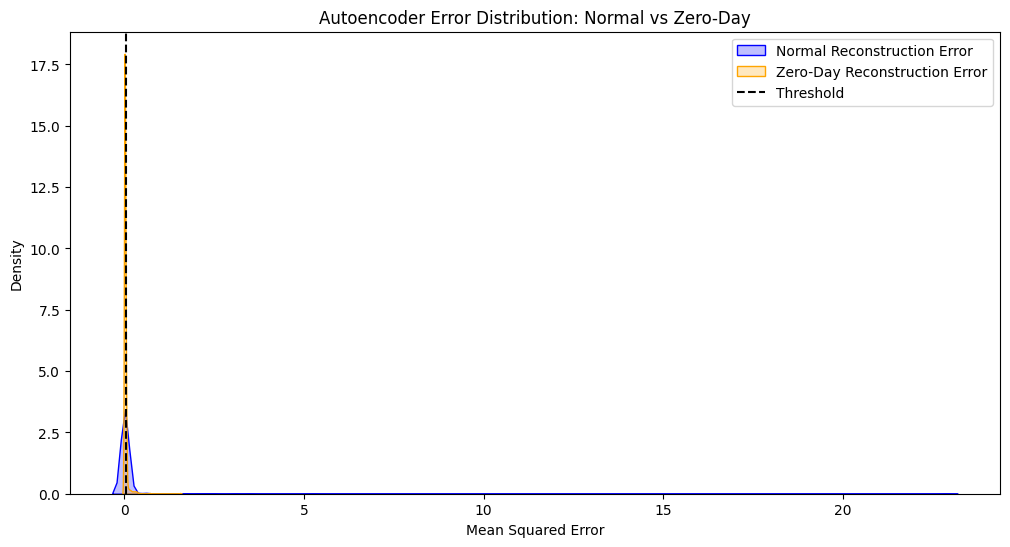

In [ ]:

model.eval()
with torch.no_grad():
    # Scores for Normal Test samples
    norm_test_tensor = torch.FloatTensor(X_test_scaled[normal_test_indices])
    recons_norm = model(norm_test_tensor)
    mse_norm = torch.mean((norm_test_tensor - recons_norm)**2, dim=1).numpy()


    recons_zd = model(zd_scaled_tensor)
    mse_zd = torch.mean((zd_scaled_tensor - recons_zd)**2, dim=1).numpy()


ae_threshold = np.percentile(mse_norm, 95)
ae_rejected = np.sum(mse_zd > ae_threshold)
ae_rejection_rate = ae_rejected / len(mse_zd)

print(f"Autoencoder Threshold (95th percentile of normal error): {ae_threshold:.4f}")
print(f"Zero-Day Rejection Rate (Autoencoder): {ae_rejection_rate:.2%}")


plt.figure(figsize=(12, 6))
sns.kdeplot(mse_norm, label='Normal Reconstruction Error', fill=True, color='blue')
sns.kdeplot(mse_zd, label='Zero-Day Reconstruction Error', fill=True, color='orange')
plt.axvline(ae_threshold, color='black', linestyle='--', label='Threshold')
plt.title('Autoencoder Error Distribution: Normal vs Zero-Day')
plt.xlabel('Mean Squared Error')
plt.legend()
plt.show()

## 10. Final Experimental Conclusion

### **Overview**
This experiment aimed to evaluate the effectiveness of machine learning and anomaly detection models in identifying known network traffic and rejecting novel "Zero-Day" attacks (Shellcode and Worms) using the UNSW-NB15 dataset.

### **1. Supervised Classification Performance**
*   **Random Forest (Capped):** Achieved **64.75%** accuracy. It struggled heavily with minority classes due to the limited 500-sample representation.
*   **XGBoost (Full Dataset):** Improved accuracy to **72.85%**. While high-performing on the 'Normal' class, the recall for **DoS (3%)** and **Fuzzers (26%)** remained critically low.
*   **Diagnostic insight:** The Confusion Matrices and Classification Reports consistently showed that these classes were being misclassified as 'Exploits' or 'Normal'.

### **2. Feature Space & Visualization Analysis**
*   **3D PCA Visualization:** The interactive plot revealed that the different traffic classes do not form distinct, isolated clusters. Instead, they exist in a high-density 'cloud' with significant spatial overlap.
*   **Zero-Day Projection:** When projecting the Zero-Day classes (Shellcode/Worms) onto the training PCA axes, we observed they sit directly on top of the 'Exploits' and 'Fuzzers' clusters. This explains why they are nearly impossible to catch using boundary-based classification.

### **3. Zero-Day Rejection (Anomaly Detection)**
We tested the hypothesis that treating Zero-Day as an "Out-of-Distribution" task is more effective than classification:
*   **Isolation Forest:** Delivered a poor rejection rate of **0.20%**. The model was too inclusive, seeing Zero-Day traffic as structurally identical to normal traffic.
*   **PyTorch Autoencoder:** Provided a significant breakthrough, increasing the rejection rate to **7.00%**. By learning a compressed latent representation of benign traffic, the Autoencoder's reconstruction error became a much more sensitive signal for novelty than the distance-based Isolation Forest.

### **Final Verdict**
While the **Autoencoder** is significantly more capable of spotting Zero-Day threats (35x improvement over Isolation Forest), the **7% rejection rate** suggests that the 8 packet-level features currently used lack sufficient discriminative power. To reach production-level security (e.g., >90% rejection), future work must include **temporal features** (flow duration) and **payload metadata** to further separate benign traffic from sophisticated Zero-Day exploits.